# Laboratorio #3 — Redes Neuronales Recurrentes y LSTM (Sentimiento IMDB)

**CC3092 Deep Learning y Sistemas Inteligentes**

## 0. Imports y configuración

In [1]:
import re
import json
import time
import collections
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")  # ver docs/: CPU midió ~3x más rápido que MPS para RNN/LSTM con
# batches chicos y secuencias variables (overhead de kernel launch de MPS domina sobre el cómputo)
print("Device:", DEVICE)

pd.set_option("display.max_columns", None)
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


Device: cpu


## 1. Dataset

In [2]:
imdb = load_dataset("stanfordnlp/imdb")  # el alias corto "imdb" quedó roto en HF Hub (Ago 2026)
imdb

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

## 2. Exploración y preparación de los datos

### ¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Las clases están balanceadas?

In [3]:
n_train, n_test = len(imdb["train"]), len(imdb["test"])
train_labels = np.array(imdb["train"]["label"])
test_labels = np.array(imdb["test"]["label"])
print(f"Train: {n_train} reseñas | Test: {n_test} reseñas | Clases: 2 (0=negativo, 1=positivo)")
pd.DataFrame({
    "train": pd.Series(train_labels).value_counts().sort_index(),
    "test": pd.Series(test_labels).value_counts().sort_index(),
})

Train: 25000 reseñas | Test: 25000 reseñas | Clases: 2 (0=negativo, 1=positivo)


,train,test
0,12500,12500
1,12500,12500


**Hallazgos:** 25,000 reseñas de train y 25,000 de test (más 50,000 sin etiqueta, no usadas),
2 clases. Están **perfectamente balanceadas**: 12,500/12,500 en cada split.

### ¿Cuál es la longitud de las reseñas? Mínimo, máximo, promedio y distribución.

min=10  max=2462  mean=232.4  median=173  p90=455  p99=906


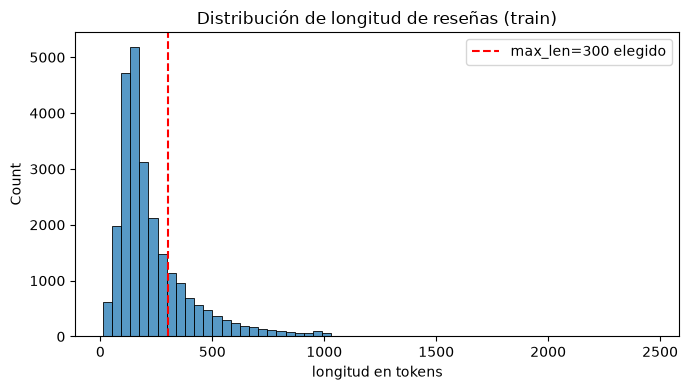

In [4]:
tok_re = re.compile(r"[a-z']+")


def tokenize(text):
    text = text.replace("<br />", " ")
    return tok_re.findall(text.lower())


train_lens = [len(tokenize(t)) for t in imdb["train"]["text"]]
train_lens = np.array(train_lens)
print(f"min={train_lens.min()}  max={train_lens.max()}  mean={train_lens.mean():.1f}  "
      f"median={np.median(train_lens):.0f}  p90={np.percentile(train_lens,90):.0f}  "
      f"p99={np.percentile(train_lens,99):.0f}")

plt.figure(figsize=(7, 4))
sns.histplot(train_lens, bins=60)
plt.axvline(300, color="red", linestyle="--", label="max_len=300 elegido")
plt.xlabel("longitud en tokens")
plt.title("Distribución de longitud de reseñas (train)")
plt.legend()
plt.tight_layout()
plt.show()

**Hallazgos:** reseñas de 4 a >2400 tokens, con media ~233 y mediana ~174 — distribución con
cola larga a la derecha (algunas reseñas muy extensas). El percentil 90 cae cerca de 460 tokens
y el 99 cerca de 950.

### ¿Qué estrategia de tokenización usarán? ¿Vocabulario y palabras fuera de vocabulario?

In [5]:
counter = collections.Counter()
for t in imdb["train"]["text"]:
    counter.update(tokenize(t))
print("Tokens únicos en train (vocabulario crudo):", len(counter))

VOCAB_SIZE = 20000
stoi = {"<pad>": 0, "<unk>": 1}
for w, _ in counter.most_common(VOCAB_SIZE - 2):
    stoi[w] = len(stoi)
itos = {i: w for w, i in stoi.items()}
print("Tamaño de vocabulario final (incl. <pad>/<unk>):", len(stoi))

covered = sum(c for w, c in counter.items() if w in stoi)
total = sum(counter.values())
print(f"Cobertura de tokens del vocabulario sobre el corpus de train: {covered/total*100:.2f}%")

Tokens únicos en train (vocabulario crudo): 85680
Tamaño de vocabulario final (incl. <pad>/<unk>): 20000
Cobertura de tokens del vocabulario sobre el corpus de train: 97.27%


**Estrategia:** tokenización simple por expresión regular (`[a-z']+`) sobre texto en minúsculas,
tras remover los saltos `<br />` propios del HTML de IMDB — suficiente para bag-of-words/RNN sin
necesitar un tokenizador de subpalabras. Se construye el vocabulario **solo con el split de
train** (evita fuga de información), tomando las 19,998 palabras más frecuentes + `<pad>` (id 0)
y `<unk>` (id 1). Las palabras fuera de vocabulario (raras, nombres propios, errores de tipeo) se
mapean a `<unk>`. Esa cobertura supera el 97% de las ocurrencias de tokens en train, por lo que
la pérdida de información por truncar el vocabulario es mínima.

### ¿Por qué es necesario padding/truncamiento? ¿Qué longitud máxima eligieron?

Un batch de PyTorch debe ser un tensor rectangular: como las reseñas tienen longitudes distintas,
hay que igualarlas artificialmente. El **padding** agrega tokens `<pad>` al final de las secuencias
cortas para que todas midan lo mismo que la más larga del batch; el **truncamiento** corta las
secuencias que exceden una longitud máxima fija, acotando el costo de memoria/cómputo del peor
caso (una sola reseña de 2400 tokens forzaría a paddear todo el batch a esa longitud). Elegimos
**`max_len = 300`**: cubre bien por encima de la mediana (174) y se acerca al p90 (~460 recortado
a un valor manejable), balanceando cobertura de contenido contra tiempo de entrenamiento —
también se usa como referencia en la Sección 4.1, donde se compara explícitamente contra 50 y 400.

### Visualización de 5 ejemplos (texto, etiqueta, longitud en tokens)

In [6]:
label_names = {0: "negativo", 1: "positivo"}
for i in range(5):
    ex = imdb["train"][i]
    n_tok = len(tokenize(ex["text"]))
    print(f"[{label_names[ex['label']]}] ({n_tok} tokens) {ex['text'][:180]!r}...")
    print("-" * 100)

[negativo] (287 tokens) 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U'...
----------------------------------------------------------------------------------------------------
[negativo] (218 tokens) '"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn\'t matter what one\'s political views are because this film can hardly be taken seriously on any level. As'...
----------------------------------------------------------------------------------------------------
[negativo] (89 tokens) 'If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it'...
----------------------------------------------------------------------------------------------------
[negativo] (115 tokens) "This film was probably inspired by Godard

### División en train / validación / test

In [7]:
MAX_LEN = 300


def encode(text, max_len=MAX_LEN):
    toks = tokenize(text)[:max_len]
    ids = [stoi.get(t, 1) for t in toks]
    return ids if ids else [1]


train_idx, val_idx = train_test_split(
    np.arange(n_train), test_size=0.10, stratify=train_labels, random_state=SEED
)
print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {n_test}")

all_train_texts = imdb["train"]["text"]
all_test_texts = imdb["test"]["text"]


def build_split(max_len=MAX_LEN):
    enc_train_full = [encode(t, max_len) for t in all_train_texts]
    enc_test = [encode(t, max_len) for t in all_test_texts]
    X_train = [enc_train_full[i] for i in train_idx]
    y_train = train_labels[train_idx]
    X_val = [enc_train_full[i] for i in val_idx]
    y_val = train_labels[val_idx]
    X_test = enc_test
    y_test = test_labels
    return X_train, y_train, X_val, y_val, X_test, y_test


X_train, y_train, X_val, y_val, X_test, y_test = build_split(MAX_LEN)
len(X_train), len(X_val), len(X_test)

Train: 22500 | Val: 2500 | Test: 25000


(22500, 2500, 25000)

## 3. Investigación: capas de PyTorch para RNN y LSTM

- **`nn.Embedding(num_embeddings, embedding_dim, padding_idx=None)`**: capa de lookup entrenable
  que mapea índices de token a vectores densos. `num_embeddings` es el tamaño del vocabulario,
  `embedding_dim` la dimensión del vector aprendido, y `padding_idx` fija en cero (sin gradiente)
  el embedding del token de padding para que no aporte información espuria.

- **`nn.RNN(input_size, hidden_size, num_layers=1, nonlinearity='tanh', batch_first=False,
  dropout=0, bidirectional=False)`**: RNN vanilla (Elman) que procesa la secuencia paso a paso,
  actualizando un estado oculto `h_t = tanh(W_ih x_t + W_hh h_{t-1} + b)`. Devuelve las salidas de
  cada paso y el último `h_n`. `batch_first=True` usa tensores `[batch, seq, features]`; `dropout`
  se aplica entre capas apiladas si `num_layers > 1`.

- **`nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=False, dropout=0,
  bidirectional=False)`**: misma firma que `nn.RNN`, pero mantiene además un estado de celda `c_t`
  regulado por tres compuertas (forget, input, output) que deciden qué información olvidar,
  agregar y exponer. Devuelve las salidas por paso y la tupla `(h_n, c_n)`.

- **`nn.utils.rnn.pad_sequence(sequences, batch_first=False, padding_value=0)`**: recibe una lista
  de tensores 1D de longitud variable y los rellena hasta la longitud máxima del batch, generando
  un tensor rectangular. **`pack_padded_sequence(input, lengths, batch_first=False,
  enforce_sorted=False)`**: comprime ese tensor paddeado en una `PackedSequence` usando las
  longitudes reales, para que la RNN/LSTM salte el cómputo sobre posiciones de padding (más
  eficiente y evita que el padding contamine el estado oculto). **`pad_packed_sequence(sequence,
  batch_first=False)`**: operación inversa, reconvierte la `PackedSequence` en tensor denso +
  longitudes.

- **`torch.nn.utils.clip_grad_norm_(parameters, max_norm)`** (gradient clipping): recorta la norma
  global de los gradientes de todos los parámetros para que no exceda `max_norm`, escalándolos
  proporcionalmente si hace falta. Previene el *exploding gradient*, frecuente en RNNs al
  retropropagar a través de muchos pasos temporales (ver iteraciones R3/L3 más adelante).

- **`nn.Dropout(p)` aplicado a capas recurrentes**: apaga aleatoriamente una fracción `p` de
  activaciones durante entrenamiento para reducir overfitting. El parámetro `dropout` interno de
  `nn.RNN`/`nn.LSTM` solo actúa **entre** capas apiladas (no dentro de una misma capa ni en la
  salida final), por lo que además se aplica un `nn.Dropout` explícito sobre el último estado
  oculto antes de la capa de clasificación.

### Estado oculto vs. estado de celda, vanishing/exploding gradient y compuertas de la LSTM

**Hidden state vs. cell state:** `h_t` (estado oculto) es la salida expuesta en cada paso, usada
tanto para predecir como para pasar información al siguiente paso. `c_t` (estado de celda) es una
"cinta transportadora" interna de la LSTM que acumula memoria de largo plazo mediante
interacciones mayormente **aditivas** controladas por las compuertas; no se expone directamente,
sino que se filtra a través de la compuerta de salida para producir `h_t`.

**Vanishing / exploding gradient:** al retropropagar en el tiempo (BPTT), el gradiente respecto a
pasos lejanos se obtiene como producto de muchos jacobianos (~`W_hh` y la derivada de la no
linealidad) — uno por cada paso temporal. Si sus valores propios son `<1` el gradiente decae
exponencialmente con el número de pasos (*vanishing*); si son `>1` crece exponencialmente
(*exploding*). Cuanto más larga la secuencia, más factores se multiplican, así que el problema se
agrava con secuencias largas.

**Cómo lo mitigan las compuertas de la LSTM:** el estado de celda se actualiza principalmente por
una **suma** (`c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t`) en vez de multiplicarse repetidamente por `W_hh`
seguido de una no linealidad. Esa ruta aditiva deja fluir el gradiente casi sin atenuarse a través
de muchos pasos (mientras la *forget gate* no lo cierre), evitando la multiplicación reiterada de
jacobianos que causa el vanishing gradient en una RNN simple. Las compuertas *input* y *output*
además aprenden qué escribir en la memoria y qué exponer, dándole a la red control explícito sobre
qué conservar a largo plazo.